# 02 — Exploratory Data Analysis (EDA)
สำรวจข้อมูลที่สะอาดแล้วใน `../data/clean/` เพื่อหาแนวโน้ม ฤดูกาล และความสัมพันธ์
ที่จะใช้ออกแบบฟีเจอร์และโมเดลพยากรณ์ความต้องการยา

**คำถามหลักที่ EDA ตอบ**
1. ยอดใช้ยาแต่ละกลุ่มมีแนวโน้มอย่างไรตามเวลา?
2. มีฤดูกาล (รายเดือน / วันในสัปดาห์ / รายชั่วโมง) ไหม?
3. ยากลุ่มไหนใช้เยอะ/ผันผวนสูง (เสี่ยงขาดแคลน)?
4. กลุ่มยาต่าง ๆ สัมพันธ์กันไหม?
5. สภาพคลังยา (วันหมดอายุ, สต็อก) และ supply chain เป็นอย่างไร?

In [19]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Tahoma', 'DejaVu Sans']
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams['axes.unicode_minus'] = False

CLEAN = Path("../data/clean")

daily   = pd.read_csv(CLEAN / "salesdaily.csv",   parse_dates=["datum"])
hourly  = pd.read_csv(CLEAN / "saleshourly.csv",  parse_dates=["datum"])
weekly  = pd.read_csv(CLEAN / "salesweekly.csv",  parse_dates=["datum"])
monthly = pd.read_csv(CLEAN / "salesmonthly.csv", parse_dates=["datum"])
atc     = pd.read_csv(CLEAN / "atc_drug_groups.csv")

DRUG_COLS = ["M01AB", "M01AE", "N02BA", "N02BE", "N05B", "N05C", "R03", "R06"]
ATC_DESC = dict(zip(atc["atc_code"], atc["description"]))

print("daily:", daily.shape, "| ช่วงเวลา:", daily["datum"].min().date(), "→", daily["datum"].max().date())
daily.head()

daily: (2106, 13) | ช่วงเวลา: 2014-01-02 → 2019-10-08


,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,year,month,hour,weekday_name
0,2014-01-02,0.0,3.67,3.4,32.40,7.0,0.0,0.0,2.0,2014,1,248,Thursday
1,2014-01-03,8.0,4.00,4.4,50.60,16.0,0.0,20.0,4.0,2014,1,276,Friday
2,2014-01-04,2.0,1.00,6.5,61.85,10.0,0.0,9.0,1.0,2014,1,276,Saturday
3,2014-01-05,4.0,3.00,7.0,41.10,8.0,0.0,3.0,0.0,2014,1,276,Sunday
4,2014-01-06,5.0,1.00,4.5,21.70,16.0,2.0,6.0,2.0,2014,1,276,Monday


## สถิติพื้นฐานของยอดใช้ยาแต่ละกลุ่ม (รายวัน)

In [20]:
stats = daily[DRUG_COLS].describe().T
stats["cv"] = stats["std"] / stats["mean"]  # coefficient of variation = ความผันผวนสัมพัทธ์
stats["description"] = stats.index.map(ATC_DESC)
stats.sort_values("cv", ascending=False)[["mean", "std", "cv", "min", "max", "description"]]

,mean,std,cv,min,max,description
N05C,0.593522,1.092988,1.841528,0.0,9.000000,Psycholeptics - Hypnotics & sedatives
R03,5.512262,6.428736,1.166261,0.0,45.000000,Drugs for obstructive airway diseases
R06,2.900198,2.415816,0.832983,0.0,15.000000,Antihistamines for systemic use
N05B,8.853627,5.605605,0.633142,0.0,54.833333,Psycholeptics - Anxiolytics
N02BA,3.880441,2.384010,0.614366,0.0,16.000000,Analgesics/antipyretics - Salicylic acid deriv...
M01AE,3.895830,2.133337,0.547595,0.0,14.463000,Anti-inflammatory/antirheumatic - Propionic ac...
M01AB,5.033683,2.737579,0.543852,0.0,17.340000,Anti-inflammatory/antirheumatic - Acetic acid ...
N02BE,29.917095,15.590966,0.521139,0.0,161.000000,Analgesics/antipyretics - Pyrazolones & Anilides


> **CV (coefficient of variation) สูง = ผันผวนมาก → พยากรณ์ยาก → เสี่ยงขาดแคลน** จุดที่ระบบ MedCast ต้องเฝ้าระวังเป็นพิเศษ

## 1) แนวโน้มยอดใช้ยาตามเวลา (รายเดือน)

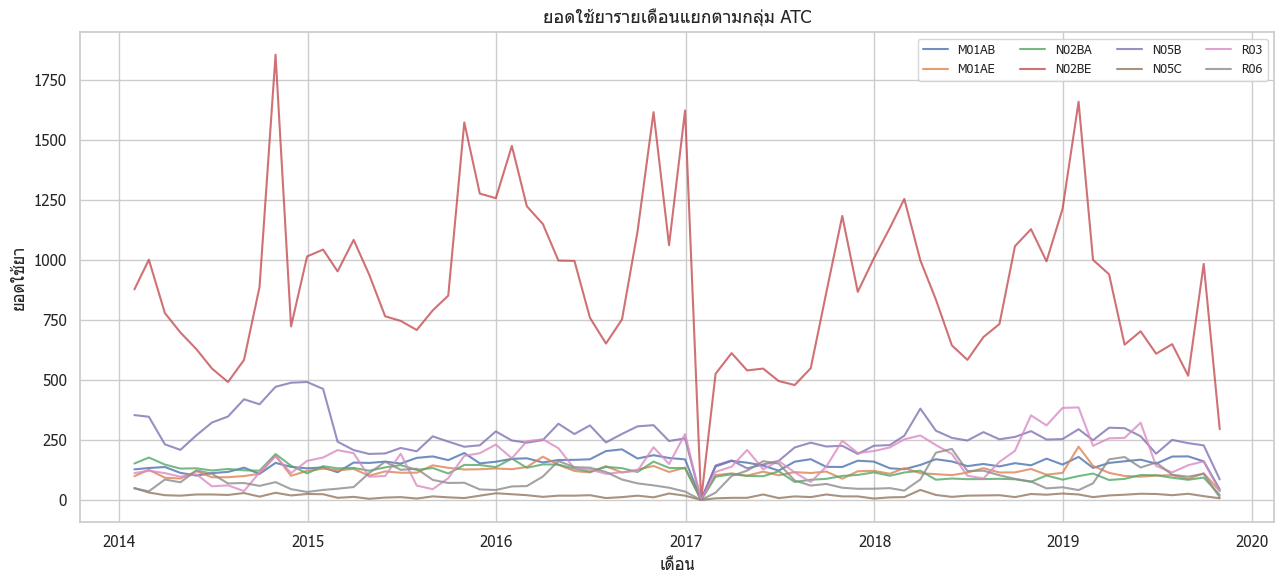

In [21]:
fig, ax = plt.subplots(figsize=(13, 6))
for col in DRUG_COLS:
    ax.plot(monthly["datum"], monthly[col], label=col, alpha=0.8)
ax.set_title("ยอดใช้ยารายเดือนแยกตามกลุ่ม ATC")
ax.set_xlabel("เดือน"); ax.set_ylabel("ยอดใช้ยา")
ax.legend(ncol=4, fontsize=9)
plt.tight_layout(); plt.show()

## 2) ฤดูกาลรายเดือน (เฉลี่ยตามเดือนปฏิทิน)
ดูว่ายาตัวไหน "พีค" เดือนไหน — สำคัญต่อการเตรียมสต็อกล่วงหน้า

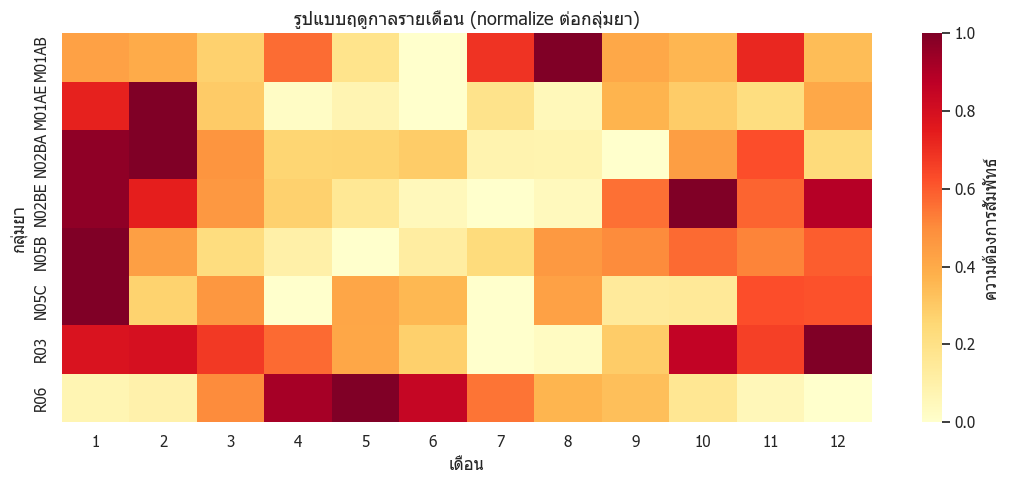

In [22]:
daily["month"] = daily["datum"].dt.month
monthly_profile = daily.groupby("month")[DRUG_COLS].mean()

# normalize 0-1 ต่อกลุ่มยา เพื่อเทียบรูปแบบฤดูกาล (ไม่ใช่ขนาด)
norm = (monthly_profile - monthly_profile.min()) / (monthly_profile.max() - monthly_profile.min())

fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(norm.T, cmap="YlOrRd", annot=False, cbar_kws={"label": "ความต้องการสัมพัทธ์"}, ax=ax)
ax.set_title("รูปแบบฤดูกาลรายเดือน (normalize ต่อกลุ่มยา)")
ax.set_xlabel("เดือน"); ax.set_ylabel("กลุ่มยา")
plt.tight_layout(); plt.show()

## 3) รูปแบบตามวันในสัปดาห์ และรายชั่วโมง

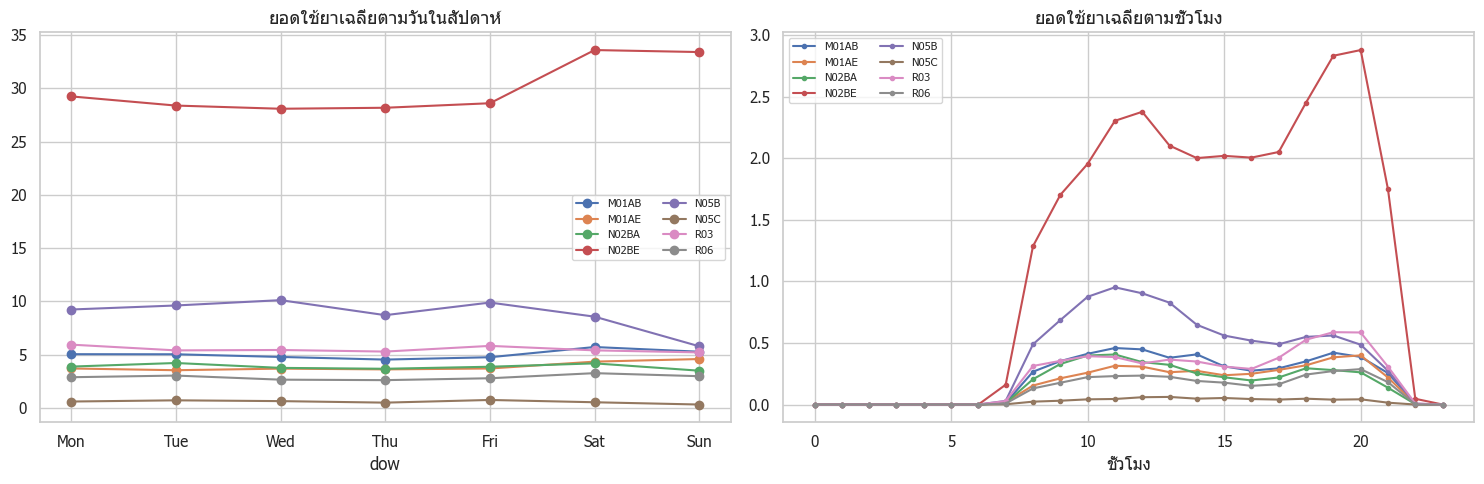

In [23]:
daily["dow"] = daily["datum"].dt.dayofweek  # 0=จันทร์
hourly["hour_of_day"] = hourly["datum"].dt.hour

dow_profile = daily.groupby("dow")[DRUG_COLS].mean()
hour_profile = hourly.groupby("hour_of_day")[DRUG_COLS].mean()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
dow_profile.plot(ax=axes[0], marker="o")
axes[0].set_title("ยอดใช้ยาเฉลี่ยตามวันในสัปดาห์")
axes[0].set_xticks(range(7))
axes[0].set_xticklabels(["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])
axes[0].legend(ncol=2, fontsize=8)

hour_profile.plot(ax=axes[1], marker=".")
axes[1].set_title("ยอดใช้ยาเฉลี่ยตามชั่วโมง")
axes[1].set_xlabel("ชั่วโมง")
axes[1].legend(ncol=2, fontsize=8)
plt.tight_layout(); plt.show()

## 4) ความสัมพันธ์ระหว่างกลุ่มยา
ถ้ายาสองกลุ่มสัมพันธ์กันสูง โมเดลพยากรณ์ตัวหนึ่งช่วยอนุมานอีกตัวได้

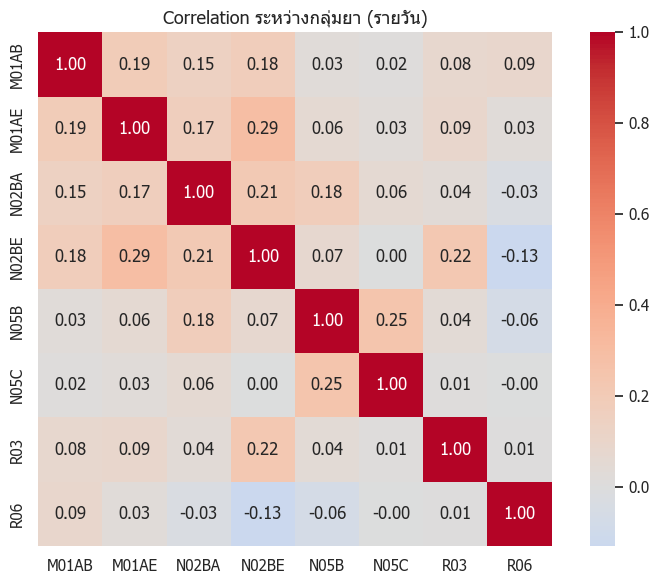

In [24]:
corr = daily[DRUG_COLS].corr()
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True, ax=ax)
ax.set_title("Correlation ระหว่างกลุ่มยา (รายวัน)")
plt.tight_layout(); plt.show()

## 5) การกระจายตัว + แนวโน้มเชิงเส้น (rolling mean 30 วัน)

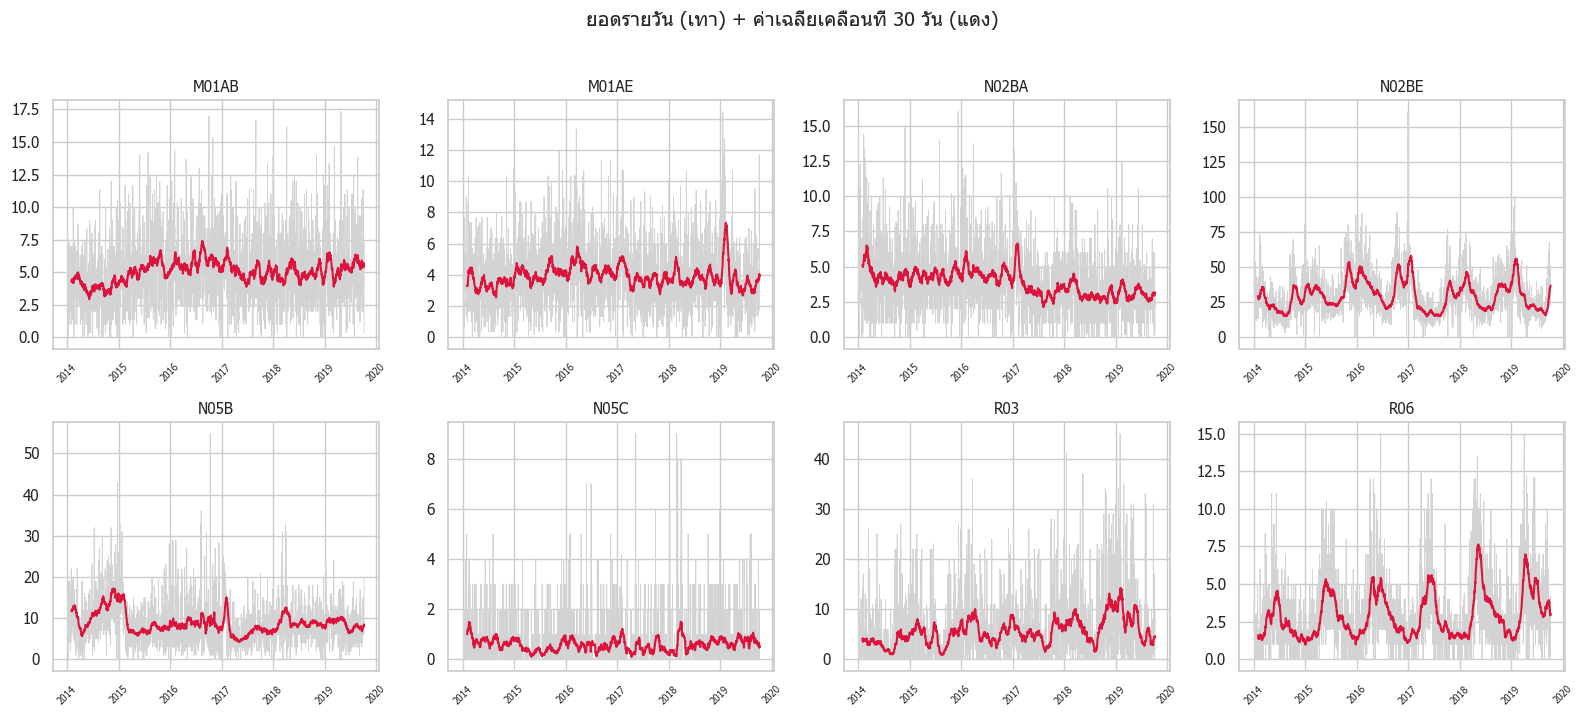

In [25]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.ravel(), DRUG_COLS):
    s = daily.set_index("datum")[col]
    ax.plot(s.index, s.values, color="lightgray", lw=0.6)
    ax.plot(s.index, s.rolling(30).mean(), color="crimson", lw=1.5)
    ax.set_title(col, fontsize=11)
    ax.tick_params(axis="x", rotation=45, labelsize=7)
fig.suptitle("ยอดรายวัน (เทา) + ค่าเฉลี่ยเคลื่อนที่ 30 วัน (แดง)", y=1.02)
plt.tight_layout(); plt.show()

## 6) คลังยา (inventory) — วันหมดอายุและสต็อก

ยาที่หมดอายุแล้ว: 89
ยาที่จะหมดอายุใน 90 วัน: 0


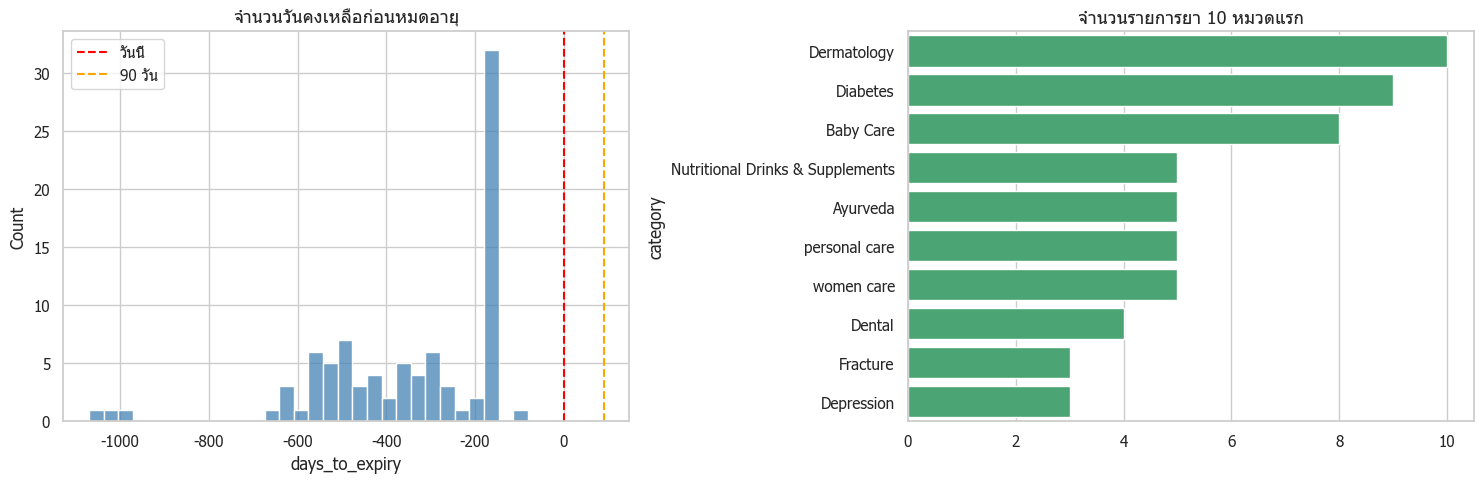

In [26]:
inv = pd.read_csv(CLEAN / "inventory.csv", parse_dates=["expiry_date"])
today = pd.Timestamp("2026-06-04")
inv["days_to_expiry"] = (inv["expiry_date"] - today).dt.days

print("ยาที่หมดอายุแล้ว:", (inv["days_to_expiry"] < 0).sum())
print("ยาที่จะหมดอายุใน 90 วัน:", inv["days_to_expiry"].between(0, 90).sum())

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(inv["days_to_expiry"].dropna(), bins=30, ax=axes[0], color="steelblue")
axes[0].axvline(0, color="red", ls="--", label="วันนี้")
axes[0].axvline(90, color="orange", ls="--", label="90 วัน")
axes[0].set_title("จำนวนวันคงเหลือก่อนหมดอายุ"); axes[0].legend()

top_cat = inv["category"].value_counts().head(10)
sns.barplot(x=top_cat.values, y=top_cat.index, ax=axes[1], color="mediumseagreen")
axes[1].set_title("จำนวนรายการยา 10 หมวดแรก")
plt.tight_layout(); plt.show()

## 7) Supply chain — demand vs optimal stock และกลยุทธ์เติมสต็อก

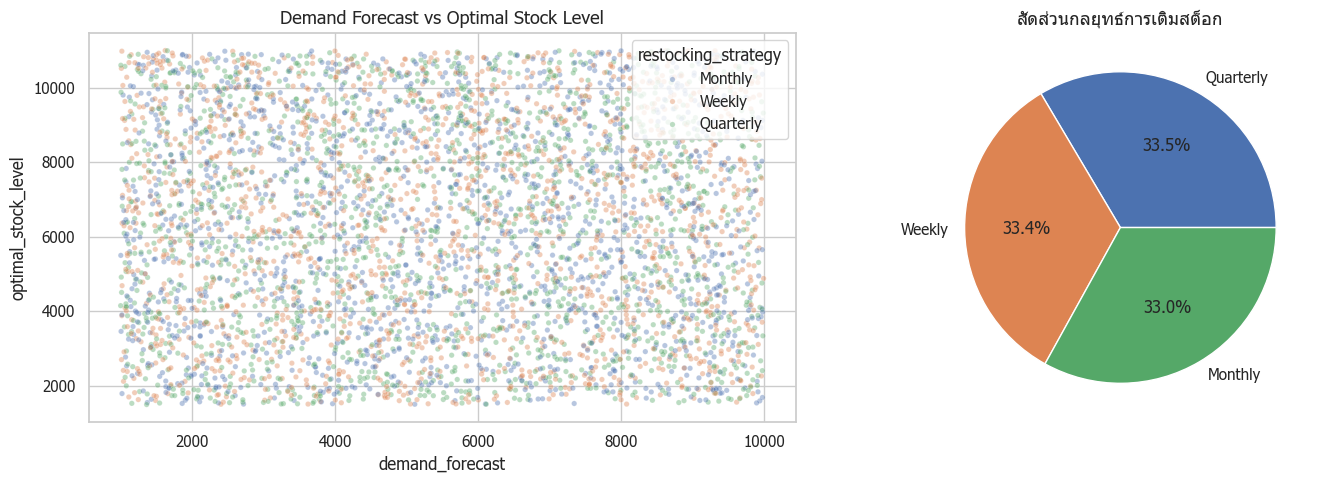

In [27]:
sc = pd.read_csv(CLEAN / "supply_chain.csv")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.scatterplot(
    data=sc.sample(min(5000, len(sc)), random_state=0),
    x="demand_forecast", y="optimal_stock_level",
    hue="restocking_strategy", alpha=0.4, s=15, ax=axes[0],
)
axes[0].set_title("Demand Forecast vs Optimal Stock Level")

sc["restocking_strategy"].value_counts().plot.pie(
    autopct="%1.1f%%", ax=axes[1], ylabel=""
)
axes[1].set_title("สัดส่วนกลยุทธ์การเติมสต็อก")
plt.tight_layout(); plt.show()

## สรุปข้อค้นพบ (Key Takeaways)

- **กลุ่มยาที่ผันผวนสูง (CV สูง)** คือกลุ่มที่ระบบต้องเฝ้าระวังการขาดแคลนมากที่สุด → ตั้ง threshold เตือนให้ไวขึ้น
- **มีฤดูกาลชัดเจน** ทั้งรายเดือน วันในสัปดาห์ และรายชั่วโมง → ฟีเจอร์ `month`, `dayofweek`, `hour`, lag features จะช่วยโมเดลได้มาก
- **บางกลุ่มยา correlation สูง** → ใช้เป็นฟีเจอร์ร่วม (cross-series) ในโมเดลพยากรณ์ได้
- **คลังยา**: มีรายการที่ใกล้/เลยวันหมดอายุ → เชื่อมกับการพยากรณ์เพื่อหมุนเวียนสต็อก (FEFO)

ขั้นต่อไป → `03_feature_engineer.ipynb`: สร้าง lag, rolling, ฟีเจอร์เวลา และ label สำหรับพยากรณ์